In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_parquet('final.parquet')
df.head()

,index_x,time,pm10,pm2_5,us_aqi,us_aqi_pm2_5,us_aqi_pm10,nitrogen_dioxide,us_aqi_nitrogen_dioxide,latitude,...,city,country,index_y,temperature_2m,wind_speed_10m,relative_humidity_2m,latitudereal,longitudereal,index,carbon_monoxide
0,0,2020-01-01T00:00,9.6,3.5,27.0,24.0,11.0,5.7,3,36.9,...,Annaba,Algeria,0,7.2,8.2,90,36.801403,7.805519,0,165.0
1,1,2020-01-01T01:00,9.4,3.5,NaN,NaN,NaN,5.2,3,36.9,...,Annaba,Algeria,1,6.3,8.4,91,36.801403,7.805519,1,167.0
2,2,2020-01-01T02:00,8.1,3.5,NaN,NaN,NaN,4.4,2,36.9,...,Annaba,Algeria,2,6.2,10.3,90,36.801403,7.805519,2,171.0
3,3,2020-01-01T03:00,7.9,3.9,NaN,NaN,NaN,4.9,2,36.9,...,Annaba,Algeria,3,6.6,9.4,88,36.801403,7.805519,3,171.0
4,4,2020-01-01T04:00,8.3,4.1,NaN,NaN,NaN,8.6,4,36.9,...,Annaba,Algeria,4,6.7,9.2,88,36.801403,7.805519,4,172.0


In [3]:
df.columns

Index(['index_x', 'time', 'pm10', 'pm2_5', 'us_aqi', 'us_aqi_pm2_5',
       'us_aqi_pm10', 'nitrogen_dioxide', 'us_aqi_nitrogen_dioxide',
       'latitude', 'longitude', 'city', 'country', 'index_y', 'temperature_2m',
       'wind_speed_10m', 'relative_humidity_2m', 'latitudereal',
       'longitudereal', 'index', 'carbon_monoxide'],
      dtype='object')

   ---------------------------------------- 0.0/350.8 MB ? eta -:--:--
   ---------------------------------------- 0.1/350.8 MB 1.7 MB/s eta 0:03:33
   ---------------------------------------- 0.1/350.8 MB 1.7 MB/s eta 0:03:26
   ---------------------------------------- 0.2/350.8 MB 1.8 MB/s eta 0:03:17
   ---------------------------------------- 0.4/350.8 MB 2.5 MB/s eta 0:02:21
   ---------------------------------------- 0.6/350.8 MB 2.7 MB/s eta 0:02:09
   ---------------------------------------- 0.6/350.8 MB 2.7 MB/s eta 0:02:10
   ---------------------------------------- 0.8/350.8 MB 2.7 MB/s eta 0:02:12
   ---------------------------------------- 1.0/350.8 MB 2.9 MB/s eta 0:02:01
   ---------------------------------------- 1.1/350.8 MB 3.1 MB/s eta 0:01:52
   ---------------------------------------- 1.4/350.8 MB 3.3 MB/s eta 0:01:46
   ---------------------------------------- 1.5/350.8 MB 3.4 MB/s eta 0:01:44
   ---------------------------------------- 1.7/350.8 MB 3.4 MB/s eta 0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.30.0 requires protobuf<5,>=3.20, but you have protobuf 7.34.1 which is incompatible.


Calculated Class Weights: {0: 0.5559478504259864, 1: 0.8950258772438364, 2: 11.907028921998247}


C:\Users\omare\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5943 - loss: 0.8277 - val_accuracy: 0.6861 - val_loss: 0.7059
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6747 - loss: 0.6994 - val_accuracy: 0.6999 - val_loss: 0.6711
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6906 - loss: 0.6567 - val_accuracy: 0.7181 - val_loss: 0.6245
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7024 - loss: 0.6278 - val_accuracy: 0.7292 - val_loss: 0.5972
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7103 - loss: 0.6083 - val_accuracy: 0.7270 - val_loss: 0.5948
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7125 - loss: 0.5911 - val_accuracy: 0.7283 - val_loss: 0.5933
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7147 - loss: 0.5795 - val_accuracy: 0.7363 - val_loss: 0.5742
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7182 - loss: 0.5667 - val_accuracy: 0.

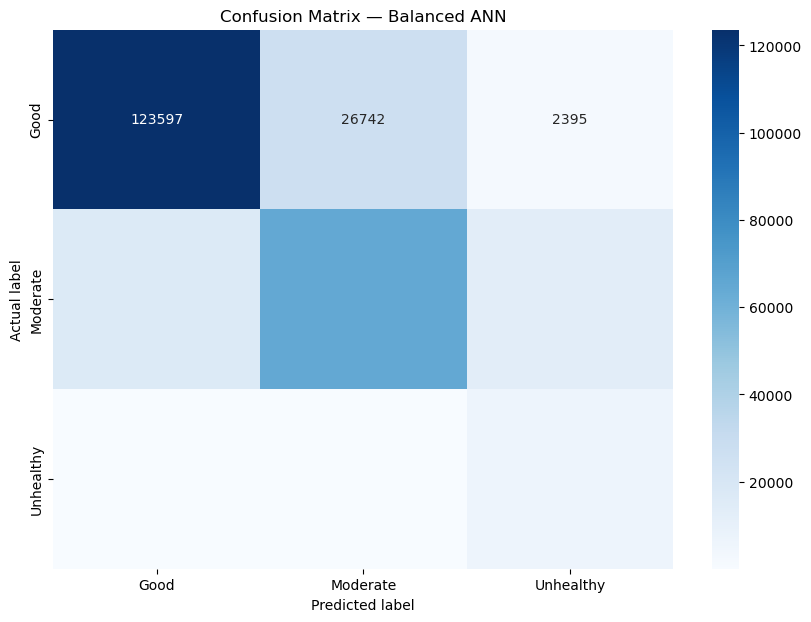

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. LOAD DATA
df = pd.read_parquet('final.parquet')

# 2. FEATURE ENGINEERING
df['time'] = pd.to_datetime(df['time'])
df['hour'] = df['time'].dt.hour
df['month'] = df['time'].dt.month
df['day_of_week'] = df['time'].dt.dayofweek

def bin_aqi(aqi):
    if aqi <= 50: return 0
    elif aqi <= 100: return 1
    else: return 2

df['aqi_label'] = df['us_aqi'].apply(bin_aqi)

# 3. DEFINE FEATURES & TARGET
# Removing target leakage and keeping only predictive features
drop_cols = ['index_x', 'index_y', 'index', 'time', 'us_aqi', 'aqi_label',
             'pm10', 'pm2_5', 'us_aqi_pm2_5', 'us_aqi_pm10']

X = df.drop(columns=[col for col in drop_cols if col in df.columns])
y = df['aqi_label']

# 4. CATEGORICAL ENCODING & SPLITTING
X = pd.get_dummies(X, columns=['city', 'country'], drop_first=True).astype(float)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- CALCULATE CLASS WEIGHTS ---
# This forces the model to pay more attention to the 'Unhealthy' class
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
print(f"Calculated Class Weights: {class_weight_dict}")

# 5. SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. BUILD ANN MODEL
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),  
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

# 7. TRAIN
# Using class_weight to penalize the model more for missing "Unhealthy" days
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train, 
    validation_split=0.2, 
    epochs=30, 
    batch_size=4096, 
    callbacks=[early_stop], 
    class_weight=class_weight_dict,
    verbose=1
)

# 8. PREDICT
probabilities = model.predict(X_test_scaled)
predictions = np.argmax(probabilities, axis=1)

# 9. EVALUATION & VISUALIZATION
print("\nANN Classification Report (Balanced):")
print(classification_report(y_test, predictions, target_names=['Good', 'Moderate', 'Unhealthy']))

labels = ['Good', 'Moderate', 'Unhealthy']
cm = metrics.confusion_matrix(y_test, predictions)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix — Balanced ANN')
plt.show()